In [2]:
# Set up sys.path so that 'src/spindle_dev' is importable as 'spindle_dev'
import sys
import importlib
from pathlib import Path

project_root = '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev'
src_path = Path(project_root) / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import spindle_dev
# Reload to pick up code changes without restarting the kernel
importlib.reload(spindle_dev)

/home/NAS/sarkah1/miniforge3/envs/spatial_cpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'spindle_dev' from '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/__init__.py'>

In [3]:
import scanpy as sc

In [4]:
! ls /home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/insitupy_demo_data_xenium/

xenium_hbraincancer		  xenium_human_kidney_nondiseased.h5ad
xenium_hbreastcancer		  xenium_human_kidney_nondiseased_index
xenium_hkidney			  xenium_human_lung_cancer.h5ad
xenium_hlungcancer		  xenium_human_lung_cancer_index
xenium_hlymphnode		  xenium_human_lymph_node_5k.h5ad
xenium_hlymphnode_5k		  xenium_human_lymph_node_5k_index
xenium_hpancreas		  xenium_human_lymph_node.h5ad
xenium_hskin			  xenium_human_lymph_node_index
xenium_human_brain_cancer.h5ad	  xenium_human_pancreatic_cancer.h5ad
xenium_human_brain_cancer_index   xenium_human_pancreatic_cancer_index
xenium_human_breast_cancer.h5ad   xenium_human_skin_melanoma.h5ad
xenium_human_breast_cancer_index  xenium_human_skin_melanoma_index


In [5]:
prefix = "/home/NAShome/sarkah1/accre_transfer"

In [6]:
adata = sc.read_h5ad(f"{prefix}/data/sarkar_lab/zenodo_data/2023_xenium_human_breast_cancer/adata.h5ad")

/tmp/ipykernel_566161/4123331657.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Cluster"], spot_size=13)


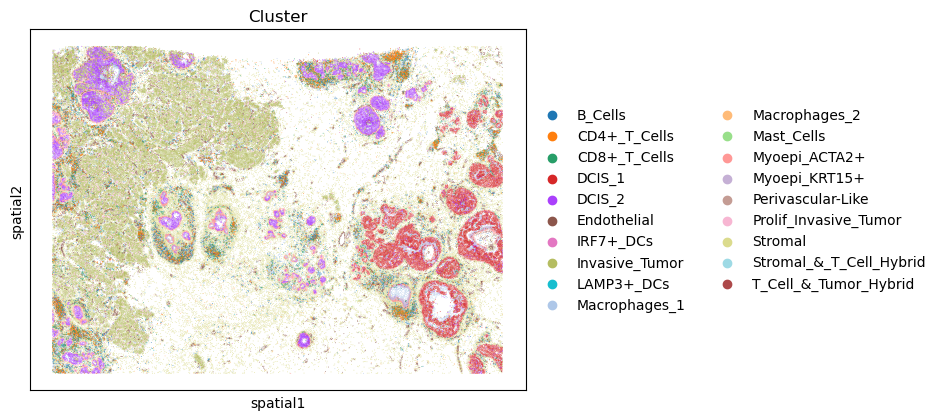

In [7]:
adata = adata[adata.obs.loc[adata.obs.Cluster != "Unlabeled"].index, :].copy()
sc.pl.spatial(adata, color=["Cluster"], spot_size=13)

In [9]:
# Reload spindle_dev metrics, index, and package after code changes
import importlib
import spindle_dev
import spindle_dev.metrics as metrics
import spindle_dev.index as index
import spindle_dev.preprocessing as preprocessing
import spindle_dev.plotting as plotting

# Reload in dependency order so new symbols are available
importlib.reload(metrics)
importlib.reload(index)
importlib.reload(preprocessing)
importlib.reload(plotting)
importlib.reload(spindle_dev)
import spindle_dev.typing as typing
importlib.reload(typing)
import spindle_dev.test as test
import spindle_dev.search as search
importlib.reload(test)
importlib.reload(search)

<module 'spindle_dev.search' from '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/search.py'>

In [21]:
import numpy as np
import pandas as pd

In [10]:
def prepare_to_index(adata, resolution=0.2, min_final_size=20):
    coords = adata.obsm["spatial"]
    tiles = preprocessing.build_quadtree_tiles(coords, max_pts=200, min_side=0.0, max_depth=40)
    num_genes = adata.n_vars
    genes_work, gene_idx = spindle_dev.preprocessing.topvar_genes(adata, G=num_genes)  
    tile_covs = spindle_dev.preprocessing.build_tile_covs_full(adata, tiles, gene_idx, n_jobs=8, eps=1e-6)
    data = index.ProcessedData(tiles, tile_covs, genes_work, adata.n_obs)
    data.reduce_dim(num_pca_components=30, n_components=2, do_umap=True)
    data.cluster_spds(cluster_distance="tree", cluster_method="leiden", resolution=resolution)
    data.assign_label_to_spots()
    data.get_corr_mean_by_cluster()
    out_dict = data.get_adaptive_runs(find_blocks=True, with_size_guard=True,min_final_size=min_final_size,max_final_size=100)
    return tiles, tile_covs, genes_work, data, out_dict

In [11]:
tiles, tile_covs, genes_work, data, out_dict = prepare_to_index(adata, min_final_size=15)

[2026-03-15 20:31:03,351] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-03-15 20:31:03,391] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
[2026-03-15 20:31:09,526] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-03-15 20:31:09,950] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-03-15 20:31:11,019] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.06878107 0.05380314 0.02646384 0.01915205 0.01300586 0.01025453
 0.00781812 0.00735731 0.00665263 0.00645236 0.00500298 0.00465103
 0.00423426 0.00416654 0.00382042 0.00364907 0.00355717 0.00348549
 0.00334294 0.00319313 0.00303316 0.00301945 0.00300855 0.00294676
 0.00288963 0.00281065 0.00275823 0.00274145 0.00271152 0.00265672]
[2026-03-15 20:31:11,021] INFO spindle_dev.index: Reducing latent features to 2 dimensions using UMAP.
/home/NAS/sarkah1/miniforge3/envs/spatial_cpu/lib/python3.12/site-p

In [14]:
data.spd_matrices.shape

(2081, 313, 313)

In [19]:
from tqdm import tqdm

In [20]:
log_cache = []
for mat in tqdm(data.spd_matrices):
    log_cache.append(index._log_spd(mat))

100%|██████████| 2081/2081 [00:51<00:00, 40.62it/s]


In [54]:
# Measure pairwise distance for all pairs of SPD matrices in the dataset
# can we make a progress bar for this? it's pretty slow
counter = 0
dist_array = []
for i in range(len(data.spd_matrices)):
    for j in range(i + 1, len(data.spd_matrices)):
        spd_i = data.spd_matrices[i]
        spd_j = data.spd_matrices[j]
        p = spd_i.shape[0]
        log_i = log_cache[i]
        log_j = log_cache[j]
        dist = np.linalg.norm(log_i - log_j, ord="fro") / np.sqrt(p)
        dist_array += [dist]
        counter += 1
        print(f"Progress: {counter}/{len(data.spd_matrices) * (len(data.spd_matrices) - 1) // 2}", end="\r")

In [55]:
len(dist_array)

2164240

In [56]:
counter = 0
pca_dist_array = []
pca_matrices = data.latent['pca'] 
for i in range(len(pca_matrices)):
    for j in range(i + 1, len(pca_matrices)):
        pca_i = pca_matrices[i]
        pca_j = pca_matrices[j]
        # take euclidean distance between two vectors 
        dist = np.linalg.norm(pca_i - pca_j)
        pca_dist_array.append(dist)
        counter += 1
        if counter % 10000 == 0:
            print(f"Progress: {counter}/{len(pca_matrices) * (len(pca_matrices) - 1) // 2}", end="\r", flush=True)

In [57]:
# normalize two distance arrays 
pca_np = np.array(pca_dist_array)
dist_np = np.array(dist_array)
# pca_dist_array = (pca_dist_array - pca_dist_array.min()) / (pca_dist_array.max() - pca_dist_array.min())
# dist_array = (dist_array - dist_array.min()) / (dist_array.max() - dist_array.min())

# pca_np = (pca_np - pca_np.mean()) / pca_np.std()
# dist_np = (dist_np - dist_np.mean()) / dist_np.std()
pca_np = (pca_np - pca_np.min()) / (pca_np.max() - pca_np.min())
dist_np = (dist_np - dist_np.min()) / (dist_np.max() - dist_np.min())

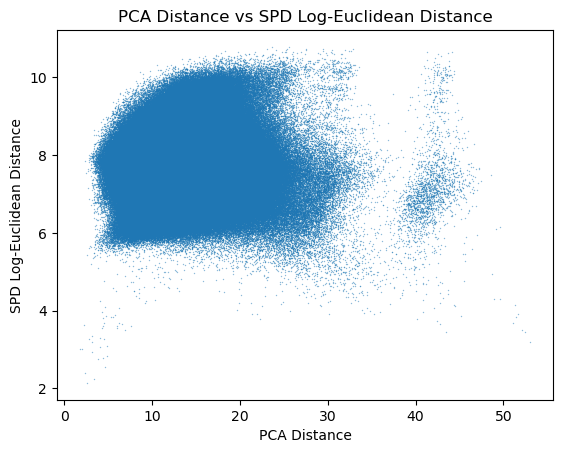

In [58]:
# Do a scatter plot of pca_dist_array vs dist_array
import matplotlib.pyplot as plt
plt.scatter(pca_dist_array, dist_array, lw=0, s=1, alpha=0.5)
plt.xlabel("PCA Distance")
plt.ylabel("SPD Log-Euclidean Distance")
plt.title("PCA Distance vs SPD Log-Euclidean Distance")
plt.show()

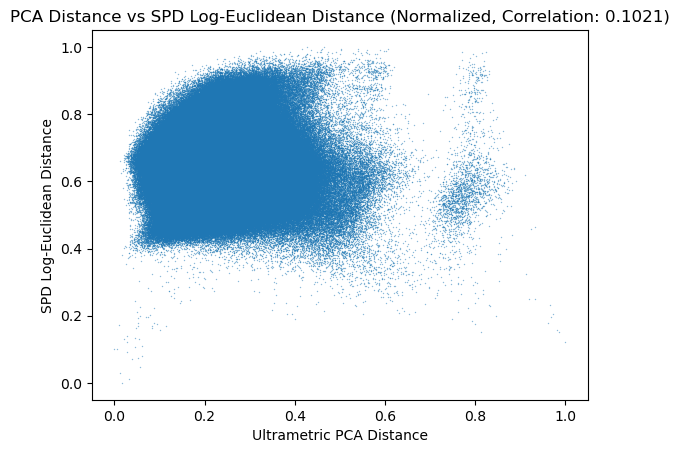

In [97]:
# Do a scatter plot of pca_dist_array vs dist_array
import matplotlib.pyplot as plt
plt.scatter(pca_np, dist_np, lw=0, s=1, alpha=0.5)
# find correlation between two distance arrays
correlation = np.corrcoef(pca_np, dist_np)[0, 1]

plt.xlabel("Ultrametric PCA Distance")
plt.ylabel("SPD Log-Euclidean Distance")
plt.title("PCA Distance vs SPD Log-Euclidean Distance (Normalized, Correlation: {:.4f})".format(correlation))
plt.show()

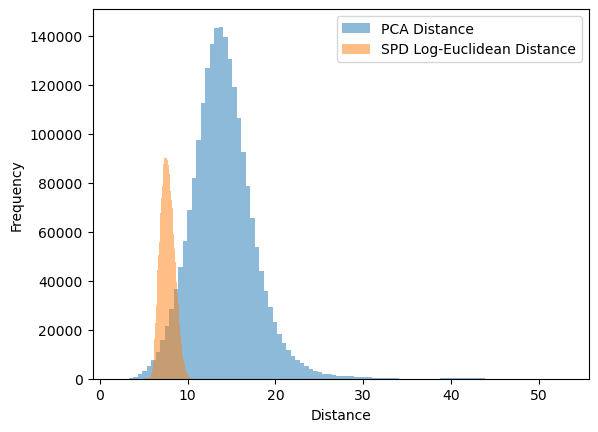

In [60]:
# Do histogram of pca_dist_array
plt.hist(pca_dist_array, bins=100, label='PCA Distance', alpha=0.5)
plt.hist(dist_array, bins=100, label='SPD Log-Euclidean Distance', alpha=0.5)
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()

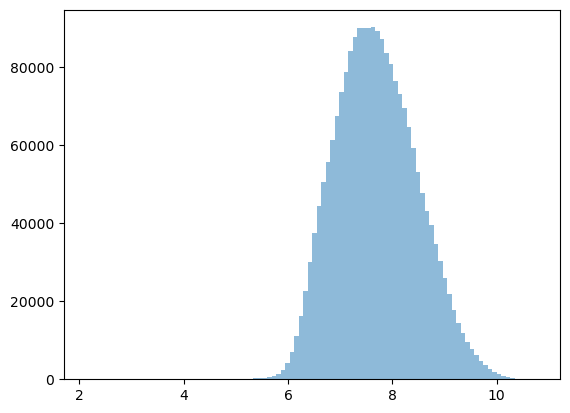

In [62]:
plt.hist(dist_array, bins=100, label='SPD Log-Euclidean Distance', alpha=0.5);

In [63]:
def spd_to_vec(mat):
    idx = np.triu_indices_from(mat)
    return mat[idx]

In [64]:
log_cache_vecs = np.array([spd_to_vec(mat) for mat in log_cache])

In [65]:
from sklearn.decomposition import PCA
pca_le = PCA(n_components=30)
Z_le = pca_le.fit_transform(log_cache_vecs)

In [67]:
Z_le.shape

(2081, 30)

In [68]:
counter = 0
pca_le_dist_array = []
pca_matrices = Z_le 
for i in range(len(pca_matrices)):
    for j in range(i + 1, len(pca_matrices)):
        pca_i = pca_matrices[i]
        pca_j = pca_matrices[j]
        # take euclidean distance between two vectors 
        dist = np.linalg.norm(pca_i - pca_j)
        pca_le_dist_array.append(dist)
        counter += 1    
        if counter % 1000 == 0:
            print(f"Progress: {counter}/{len(pca_matrices) * (len(pca_matrices) - 1) // 2}", end="\r", flush=True)

In [71]:
pca_le_np = np.array(pca_le_dist_array)
pca_le_np = (pca_le_np - pca_le_np.min()) / (pca_le_np.max() - pca_le_np.min())

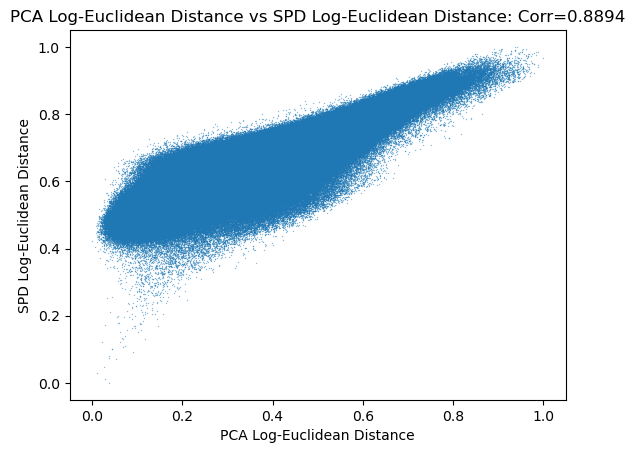

In [73]:
# Do a scatter plot of pca_le_dist_array vs dist_array
import matplotlib.pyplot as plt
plt.scatter(pca_le_np, dist_np, lw=0, s=1, alpha=0.5)
# compute correlation coefficient between pca_le_np and dist_np
corr = np.corrcoef(pca_le_np, dist_np)[0, 1]

plt.xlabel("PCA Log-Euclidean Distance")
plt.ylabel("SPD Log-Euclidean Distance")
plt.title(f"PCA Log-Euclidean Distance vs SPD Log-Euclidean Distance: Corr={corr:.4f}")
plt.show()

In [74]:
from umap import UMAP 

In [76]:
umap = UMAP(
            n_components=2,
            random_state=42,
            metric="euclidean",      # or something SPD-aware if you define it
            n_neighbors=15,          # tune these
            min_dist=0.1,
        )
Z_le_umap = umap.fit_transform(Z_le)

/home/NAS/sarkah1/miniforge3/envs/spatial_cpu/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


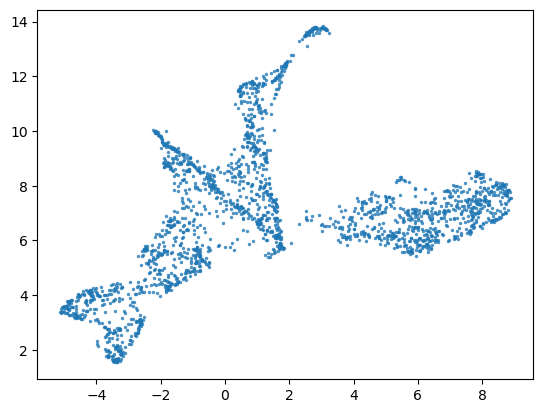

In [78]:
plt.scatter(Z_le_umap[:,0], Z_le_umap[:,1], s=6, lw=0, alpha=0.8)

In [79]:
from sklearn.cluster import KMeans

In [89]:
random_state = 42
resolution = 0.2
latent_feat = Z_le
km = KMeans(n_clusters=4, n_init=20, random_state=random_state)
labels, _, _ = index.leiden_clustering_latent(
    latent_feat, 
    k_neighbors=10, 
    resolution=resolution
)

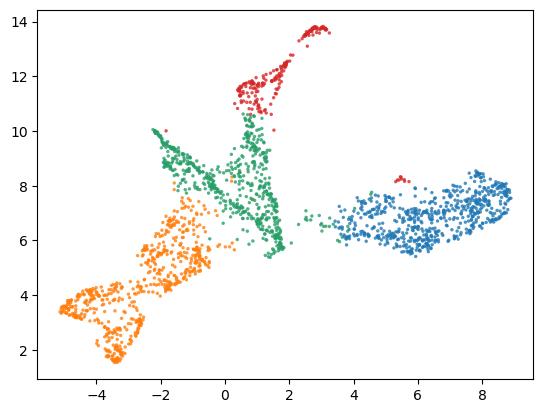

In [93]:
n_cluster = len(set(labels))
palette = sc.pl.palettes.default_20
cluster_colors = [palette[lab] for lab in labels]
plt.scatter(Z_le_umap[:,0], Z_le_umap[:,1], s=6, lw=0, alpha=0.8, c = cluster_colors)
plt.show()

In [86]:
spot_labels = {}
for i,t in enumerate(data.metadata['tiles']):
    c = labels[i]
    for id in t.idx:
        spot_labels[id] = c

In [87]:
import matplotlib.pylab as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

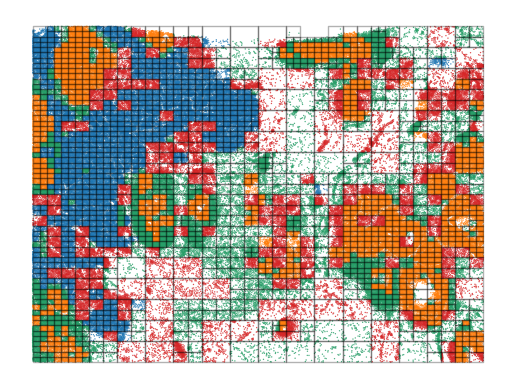

In [92]:
import numpy as np
palette = sc.pl.palettes.default_20
point_colors = [palette[lab] for lab in spot_labels.values()]

indices = np.array([int(i) for i in spot_labels.keys()])
coords = adata.obsm['spatial']
plt.scatter(coords[indices,0], coords[indices,1], s=1, c=point_colors, lw=0, alpha=0.8)
patches = []
for t in tiles:
    bbox = t.bbox if hasattr(t, "bbox") else t["bbox"]  # (xmin,ymin,xmax,ymax)
    x0, y0, x1, y1 = bbox
    patches.append(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))
pc = PatchCollection(patches, match_original=True, linewidths=0.2, edgecolors='b', alpha=0.3)
# add collection
ax = plt.gca()
ax.add_collection(pc)
ax.invert_yaxis()
ax.axis('off')
plt.show()

In [98]:
# Check if permutations for SPDs 
# are gonna reduce the off-diagonal 
# zeros, and to what extent we loose info. 
labels = data.labels

In [99]:
data.spd_matrices.shape

(2081, 313, 313)

In [101]:
data.block_dict[0]

[(0, 26),
 (26, 41),
 (41, 56),
 (56, 71),
 (71, 86),
 (86, 101),
 (101, 121),
 (121, 136),
 (136, 151),
 (151, 166),
 (166, 184),
 (184, 208),
 (208, 232),
 (232, 247),
 (247, 262),
 (262, 313)]

In [116]:
num_clusters = len(set(labels))
cluster_to_indices = {i: np.where(labels == i)[0] for i in range(num_clusters)}
for cluster_id in cluster_to_indices:
    indices = cluster_to_indices[cluster_id]
    spd_mats = data.spd_matrices[indices]
    # compute mean SPD matrix for this cluster
    permutation = data.perm_list[cluster_id]
    # take a random permulation 
    random_permutation = np.random.permutation(spd_mats[0].shape[0])
    # apply permutation to each SPD matrix in this cluster
    block_runs = data.block_dict[cluster_id]
    permuted_mats = []
    ratio_values = []
    random_perm_ratio_values = []
    for mat in spd_mats:
        permutated_mat = mat[np.ix_(permutation, permutation)]
        # keep an alternative random permutation for control
        random_mat = mat[np.ix_(random_permutation, random_permutation)]
        # make the diagonals zero for both permuted and random matrices to focus on off-diagonal values
        np.fill_diagonal(permutated_mat, 0)
        np.fill_diagonal(random_mat, 0)
        for block_idx, (block_start, block_end) in enumerate(block_runs):
            A_blk = permutated_mat[block_start:block_end, block_start:block_end]
            # after this permutation 
            # absolute value of A_blk 
            # vs absolute values outside of A_blk (within 
            # block_start block end range, block_start:block_end, 0:block_start
            # and block_end+1:end)
            # 0:block_start, block_start:block_end
            # block_end+1:end, block_start:block_end
            # we want to see if the values in A_blk are higher than the values outside of
            outside_blk = np.concatenate([
                permutated_mat[0:block_start, block_start:block_end].flatten(), # upper rectangle
                permutated_mat[block_end+1:, block_start:block_end].flatten(), # lower rectangle
                permutated_mat[block_start:block_end, 0:block_start].flatten(), # left rectangle
                permutated_mat[block_start:block_end, block_end+1:].flatten() # right rectangle
            ])
            inside_blk = A_blk.flatten()
            mean_inside = np.mean(np.abs(inside_blk))
            mean_outside = np.mean(np.abs(outside_blk))
            ratio = mean_inside / (mean_outside + 1e-6)  # add small value to avoid division by zero
            ratio_values.append(ratio)

            # do for random permutation
            random_A_blk = random_mat[block_start:block_end, block_start:block_end]
            random_outside_blk = np.concatenate([
                random_mat[0:block_start, block_start:block_end].flatten(), # upper rectangle
                random_mat[block_end+1:, block_start:block_end].flatten(), # lower rectangle
                random_mat[block_start:block_end, 0:block_start].flatten(), # left rectangle
                random_mat[block_start:block_end, block_end+1:].flatten() # right rectangle
            ])
            random_mean_inside = np.mean(np.abs(random_A_blk.flatten()))
            random_mean_outside = np.mean(np.abs(random_outside_blk))
            random_ratio = random_mean_inside / (random_mean_outside + 1e-6)
            random_perm_ratio_values.append(random_ratio)
        
    break # just do one cluster for now
    


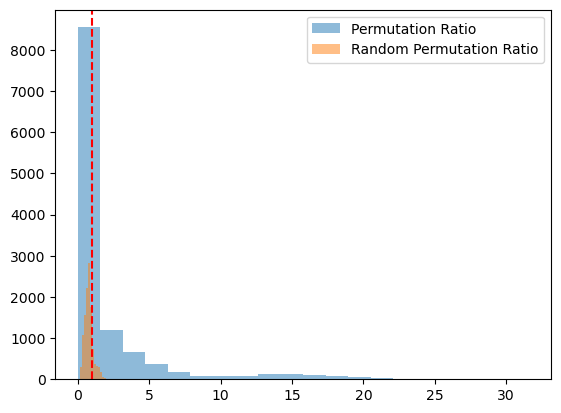

In [117]:
plt.hist(ratio_values, bins=20, alpha=0.5, label='Permutation Ratio')
plt.hist(random_perm_ratio_values, bins=20, alpha=0.5, label='Random Permutation Ratio')
plt.axvline(x=1, color='r', linestyle='--')
plt.legend()
plt.show()

In [114]:
len(ratio_values), len(random_perm_ratio_values )

(11728, 11728)